In [1]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from narwhals.selectors import categorical
from zmq.backend import first

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [3]:
dataset = pd.read_csv("fraud detection.csv")
dataset.head(3)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0


In [4]:
dataset.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [5]:
dataset.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,1.621248e-05
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,4.026442e-03
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.000000e+00
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.000000e+00
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,1.000000e+00


In [6]:
dataset["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

In [7]:
dataset["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    1048558
1         17
Name: count, dtype: int64

In [8]:
dataset.shape[0]

1048575

In [9]:
dataset.isnull().sum().sum()

np.int64(0)

In [10]:
round((dataset["isFraud"].value_counts()[1]/dataset.shape[0]) * 100,2)


np.float64(0.11)

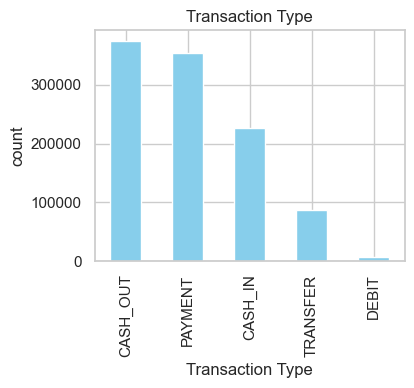

In [11]:
plt.figure(figsize = (4,3))
dataset["type"].value_counts().plot(kind="bar",title="Transaction Type", color = "skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("count")
plt.show()

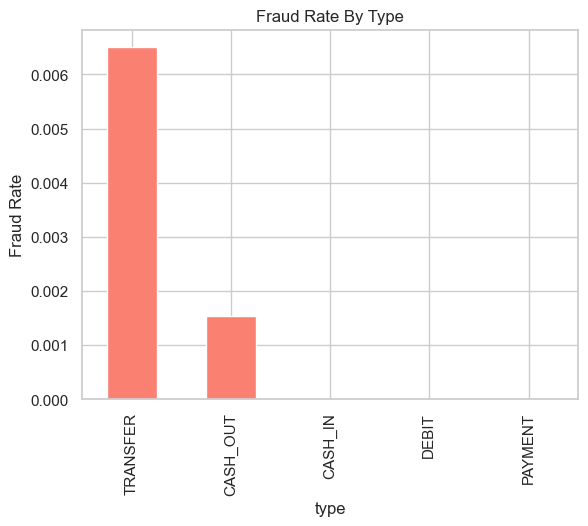

In [12]:
fraud_by_tupe = dataset.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_tupe.plot(kind="bar", title = "Fraud Rate By Type", color = "salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [13]:
dataset["amount"].describe().astype(int)

count     1048575
mean       158666
std        264940
min             0
25%         12149
50%         76343
75%        213761
max      10000000
Name: amount, dtype: int64

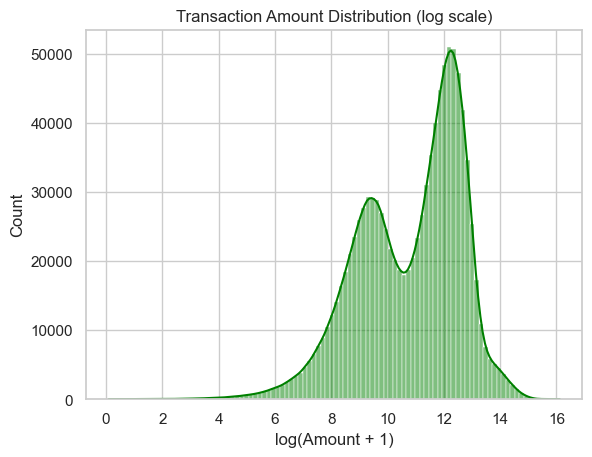

In [14]:
sns.histplot(np.log1p(dataset["amount"]), bins = 100, kde = True, color = "green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("log(Amount + 1)")
plt.show()

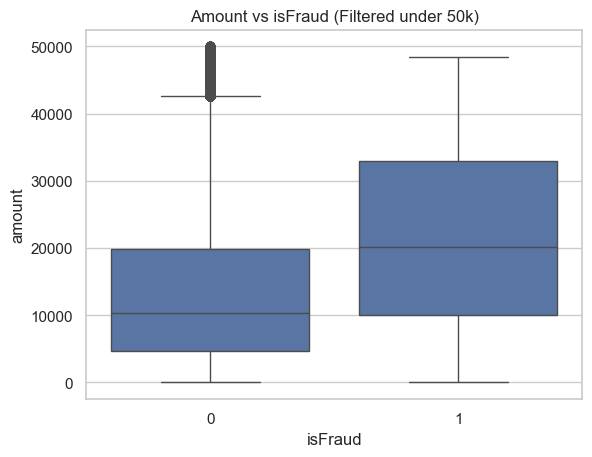

In [15]:
sns.boxplot(data = dataset[dataset["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()


In [16]:
dataset["BalanceDiffOrig"] = dataset["oldbalanceOrg"] - dataset["newbalanceOrig"]  #new column create
dataset["BalanceDiffDest"] = dataset["newbalanceDest"] - dataset["oldbalanceDest"] #new column create

In [17]:
(dataset["BalanceDiffOrig"] < 0).sum()

np.int64(221805)

In [18]:
(dataset["BalanceDiffDest"] < 0).sum()


np.int64(203566)

In [19]:
dataset.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,BalanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


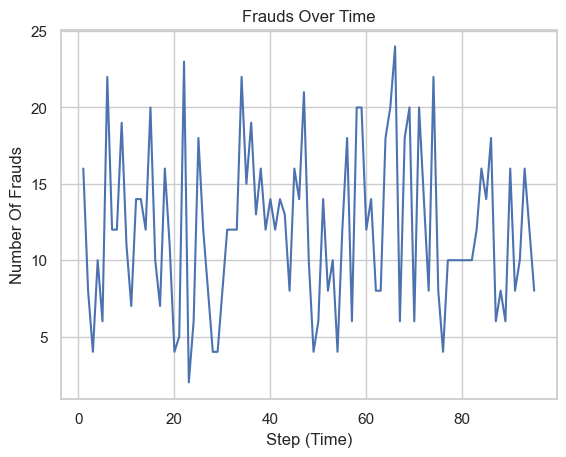

In [20]:
fraud_per_step = dataset[dataset["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(fraud_per_step.index,fraud_per_step.values, label = "Fraud per step")
plt.xlabel("Step (Time)")
plt.ylabel("Number Of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [21]:
dataset.drop(columns="step", inplace=True)

In [22]:
dataset.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,BalanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


In [23]:
top_sender = dataset["nameOrig"].value_counts().head(10)

In [24]:
top_sender

nameOrig
C821145334     2
C693814021     2
C178467166     2
C309111136     2
C2097341930    2
C894095661     2
C1041466144    2
C1322843847    2
C77405061      2
C1561789477    2
Name: count, dtype: int64

In [25]:
top_receivers = dataset["nameDest"].value_counts().head()

In [26]:
top_receivers

nameDest
C985934102     98
C1286084959    96
C1590550415    89
C248609774     88
C665576141     87
Name: count, dtype: int64

In [27]:
fraud_users = dataset[dataset["isFraud"] == 1] ["nameOrig"].value_counts()

In [28]:
fraud_users.shape

(1142,)

In [29]:
fraud_type = dataset[dataset["type"].isin(["TRANSFER","CASH_OUT"])]

In [30]:
fraud_type["type"].value_counts()

type
CASH_OUT    373641
TRANSFER     86753
Name: count, dtype: int64

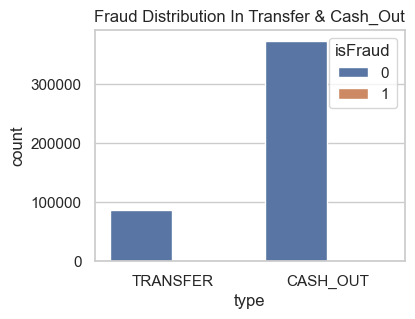

In [31]:
plt.figure(figsize=(4,3))
sns.countplot(data = fraud_type, x= "type", hue = "isFraud")
plt.title("Fraud Distribution In Transfer & Cash_Out")
plt.show()

In [32]:
corr = dataset.corr(numeric_only=True)

In [33]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,BalanceDiffDest
amount,1.000000,0.004864,-0.001133,0.215558,0.311936,0.128862,-0.002000,0.131801,0.513277
oldbalanceOrg,0.004864,1.000000,0.999047,0.093305,0.064049,0.003829,-0.001120,-0.248333,-0.118078
newbalanceOrig,-0.001133,0.999047,1.000000,0.095182,0.063725,-0.009438,-0.001142,-0.290369,-0.128184
oldbalanceDest,0.215558,0.093305,0.095182,1.000000,0.978403,-0.007552,-0.001673,-0.066818,0.134147
newbalanceDest,0.311936,0.064049,0.063725,0.978403,1.000000,-0.000495,-0.001829,-0.010073,0.336089
isFraud,0.128862,0.003829,-0.009438,-0.007552,-0.000495,1.000000,-0.000133,0.293467,0.032034
isFlaggedFraud,-0.002000,-0.001120,-0.001142,-0.001673,-0.001829,-0.000133,1.000000,0.000783,-0.001147
BalanceDiffOrig,0.131801,-0.248333,-0.290369,-0.066818,-0.010073,0.293467,0.000783,1.000000,0.256157
BalanceDiffDest,0.513277,-0.118078,-0.128184,0.134147,0.336089,0.032034,-0.001147,0.256157,1.000000


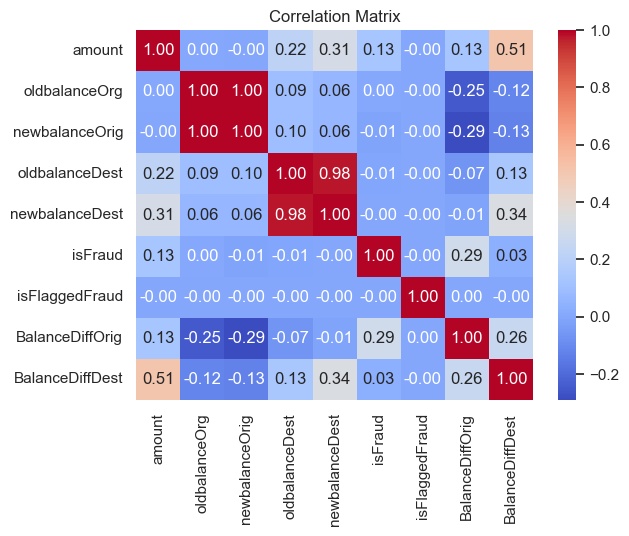

In [34]:
sns.heatmap(corr,annot=True,cmap = "coolwarm", fmt= ".2f")
plt.title("Correlation Matrix")
plt.show()

In [35]:
zero_after_transfer = dataset[
    (dataset["oldbalanceOrg"] > 0) &
    (dataset["newbalanceOrig"] == 0) &
    (dataset["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [36]:
len(zero_after_transfer)

192858

In [37]:
zero_after_transfer.head(3)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,BalanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,1,15325.0,46430.44


In [38]:
dataset["isFraud"].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [40]:
dataset.head(3)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,BalanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0


In [41]:
dataset_model = dataset.drop(["nameOrig","nameDest","isFlaggedFraud"], axis = 1)
dataset_model

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,BalanceDiffOrig,BalanceDiffDest
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,9839.64,0.00
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,1864.28,0.00
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,181.00,0.00
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,181.00,-21182.00
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,11668.14,0.00
...,...,...,...,...,...,...,...,...,...
1048570,CASH_OUT,132557.35,479803.00,347245.65,484329.37,616886.72,0,132557.35,132557.35
1048571,PAYMENT,9917.36,90545.00,80627.64,0.00,0.00,0,9917.36,0.00
1048572,PAYMENT,14140.05,20545.00,6404.95,0.00,0.00,0,14140.05,0.00
1048573,PAYMENT,10020.05,90605.00,80584.95,0.00,0.00,0,10020.05,0.00


In [42]:
categorical = ["type"]
numarical = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [43]:
y = dataset_model["isFraud"]
x = dataset_model.drop("isFraud",axis = 1)

In [44]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3, stratify=y, random_state=42)

In [45]:
#Data Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numarical),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder= "drop"

)

In [46]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [47]:
# Now Train the model
pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [48]:
y_pred = pipeline.predict(x_test)

In [49]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(314573,))

In [50]:
print(classification_report(y_test, y_pred)) #from metrix

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    314230
           1       0.02      0.97      0.03       343

    accuracy                           0.94    314573
   macro avg       0.51      0.95      0.50    314573
weighted avg       1.00      0.94      0.97    314573



In [51]:
confusion_matrix(y_test, y_pred) #from metrix

array([[295018,  19212],
       [    11,    332]])

In [52]:
accuracy_score(y_test, y_pred) #from metrics

0.9388917675706434

In [53]:
pipeline.score(x_test,y_test)

0.9388917675706434

In [54]:
import pickle

In [55]:
pickle.dump(pipeline,open("Fraud_detection.pkl", "wb"))